In [42]:
#data manipulation
import pandas as pd
import numpy as np
#visualization
import matplotlib.pyplot as plt 
import seaborn as sns
#machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#deep learning
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px    



In [2]:
data=pd.read_csv('amazon_sales_dataset.csv')

In [3]:
data.head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,808.86
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


In [4]:
data.tail(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49990,49991,2023-04-08,2689,Beauty,265.49,20,1,Asia,Cash on Delivery,2.3,239,212.39,212.39
49991,49992,2023-06-26,1809,Electronics,489.56,10,2,Europe,Credit Card,2.8,218,440.60,881.20
49992,49993,2022-12-30,4078,Fashion,33.20,0,5,Middle East,Cash on Delivery,2.5,357,33.20,166.00
49993,49994,2022-09-04,3615,Sports,306.98,15,2,North America,Wallet,4.8,438,260.93,521.86
49994,49995,2023-08-16,1942,Beauty,14.83,10,3,Europe,Wallet,2.9,77,13.35,40.05
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [6]:
data.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [7]:
data.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [8]:
data.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [9]:
data=data.dropna()

In [10]:
data=data.fillna('price')

In [11]:
data=data.drop_duplicates()

In [12]:
data['rating'].value_counts()

rating
1.9    1332
4.2    1328
3.5    1316
1.5    1303
2.2    1294
2.8    1292
1.6    1289
3.7    1280
3.9    1278
4.5    1273
2.0    1260
1.2    1260
3.3    1260
1.7    1256
4.3    1255
2.1    1254
2.9    1253
1.8    1250
4.0    1248
4.8    1246
3.6    1244
2.7    1244
1.4    1244
4.1    1241
4.7    1239
2.3    1233
3.2    1231
3.8    1230
1.3    1228
2.5    1227
2.4    1226
2.6    1223
3.4    1220
4.9    1216
1.1    1213
3.1    1209
4.6    1205
4.4    1202
3.0    1170
5.0     619
1.0     609
Name: count, dtype: int64

In [13]:
data['payment_method_copy'] = data['payment_method']

In [14]:
print("Total rating:", data['rating'].sum())
print("Total price :", data['price'].sum())

Total rating: 149815.8
Total price : 12625363.0


In [15]:
lang_conv = data.groupby('price')['rating'].sum()
print('price_rating')

price_rating


In [16]:
segment_conv = data.groupby('payment_method')['rating'].sum()
print('payment_method_rating')

payment_method_rating


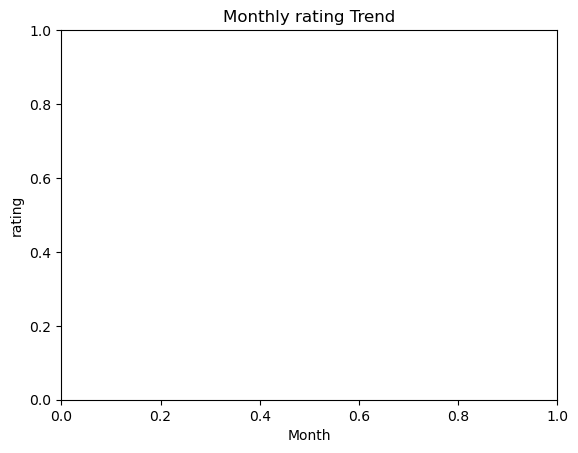

In [17]:
plt.title("Monthly rating Trend")
plt.xlabel("Month")
plt.ylabel("rating")
plt.show()

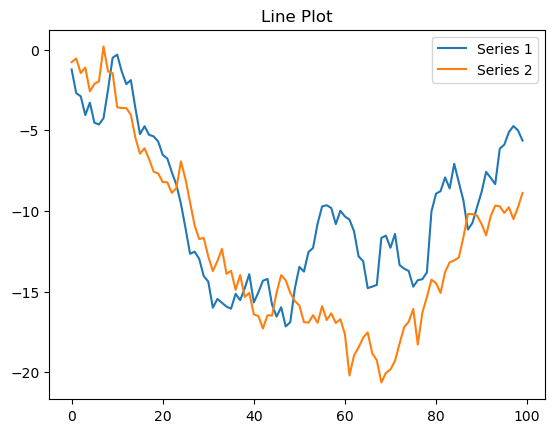

In [19]:
plt.figure()
plt.plot(np.cumsum(np.random.randn(100)), label='Series 1')
plt.plot(np.cumsum(np.random.randn(100)), label='Series 2')
plt.title('Line Plot')
plt.legend()
plt.show()

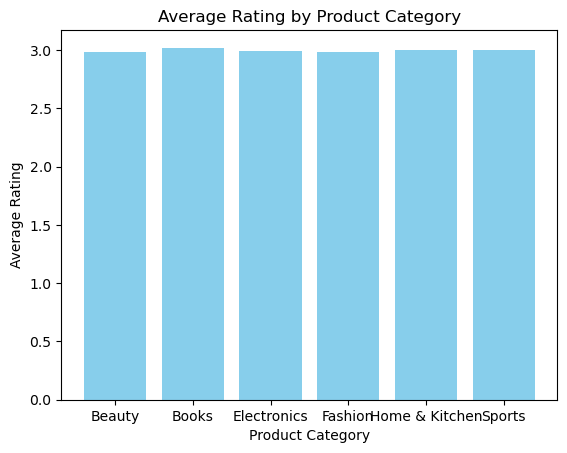

In [22]:

category_rating = data.groupby('product_category')['rating'].mean()

plt.figure()
plt.bar(category_rating.index, category_rating.values, color='skyblue')
plt.title('Average Rating by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Rating')
plt.show()

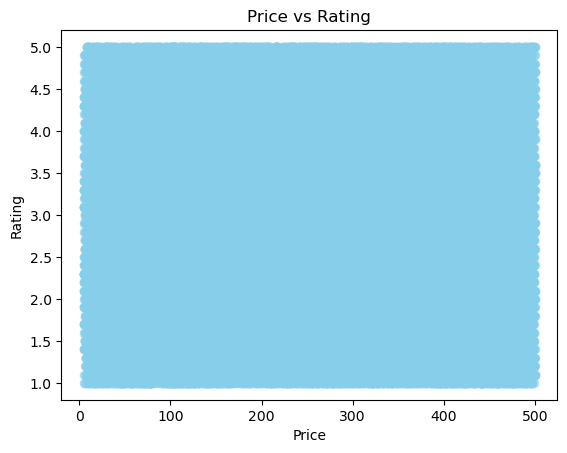

In [23]:
# Iske liye Scatter Plot use karo, Bar Plot nahi
plt.figure()
plt.scatter(data['price'], data['rating'], alpha=0.5, color='skyblue')
plt.title('Price vs Rating')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()

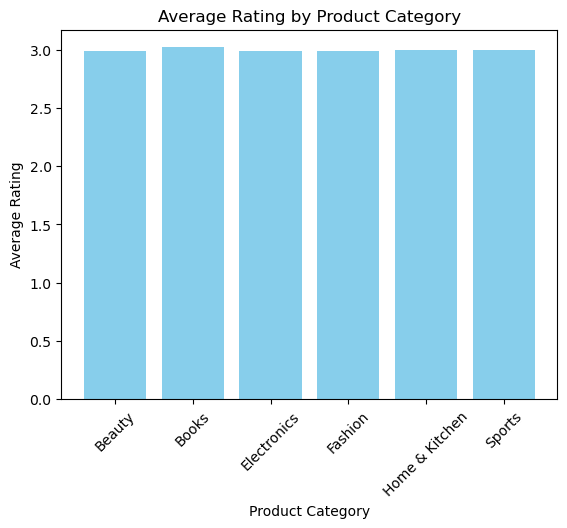

In [24]:
plt.figure()
category_rating = data.groupby('product_category')['rating'].mean()
plt.bar(category_rating.index, category_rating.values, color='skyblue')
plt.title('Average Rating by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

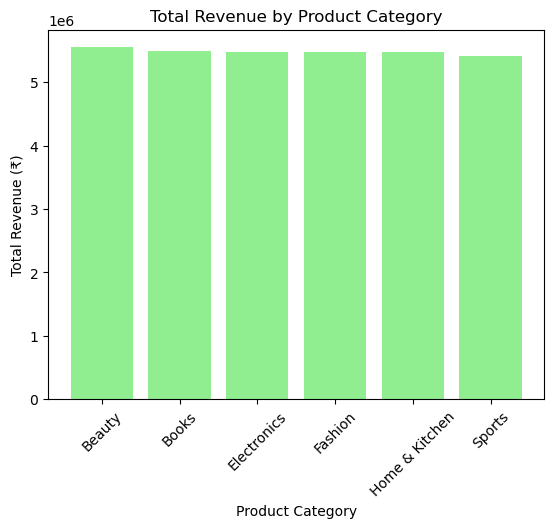

In [25]:
plt.figure()
category_revenue = data.groupby('product_category')['total_revenue'].sum()
plt.bar(category_revenue.index, category_revenue.values, color='lightgreen')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.show()

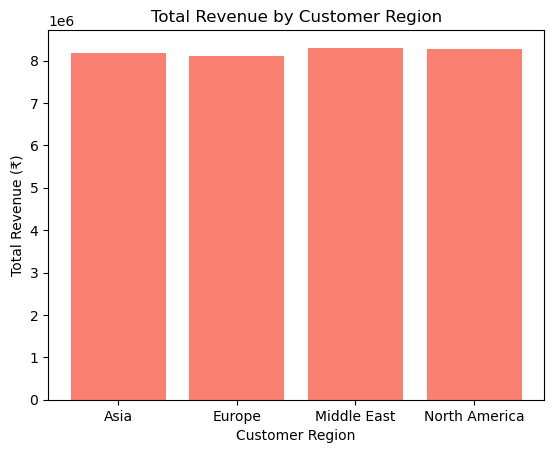

In [26]:
plt.figure()
region_revenue = data.groupby('customer_region')['total_revenue'].sum()
plt.bar(region_revenue.index, region_revenue.values, color='salmon')
plt.title('Total Revenue by Customer Region')
plt.xlabel('Customer Region')
plt.ylabel('Total Revenue (₹)')
plt.show()

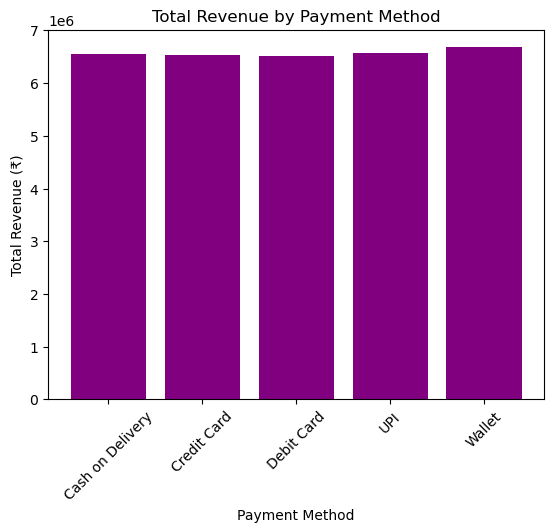

In [27]:
plt.figure()
payment_revenue = data.groupby('payment_method')['total_revenue'].sum()
plt.bar(payment_revenue.index, payment_revenue.values, color='purple')
plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.show()

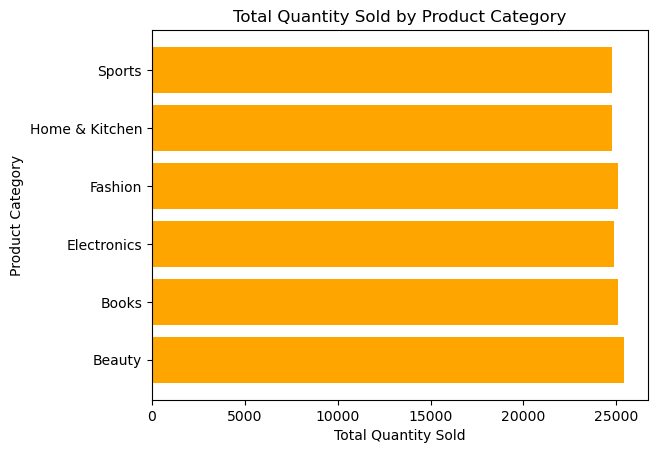

In [28]:
plt.figure()
category_qty = data.groupby('product_category')['quantity_sold'].sum()
plt.barh(category_qty.index, category_qty.values, color='orange')
plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Category')
plt.show()

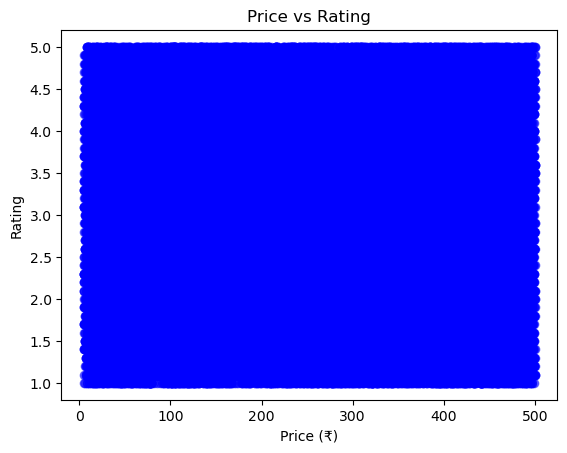

In [29]:
plt.figure()
plt.scatter(data['price'], data['rating'], alpha=0.5, color='blue')
plt.title('Price vs Rating')
plt.xlabel('Price (₹)')
plt.ylabel('Rating')
plt.show()

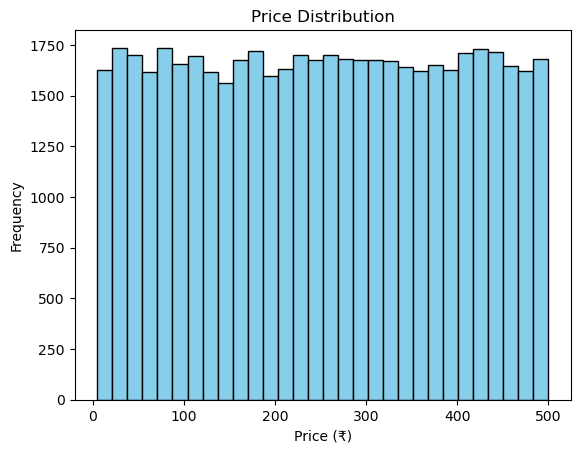

In [30]:
plt.figure()
plt.hist(data['price'], bins=30, edgecolor='black', color='skyblue')
plt.title('Price Distribution')
plt.xlabel('Price (₹)')
plt.ylabel('Frequency')
plt.show()

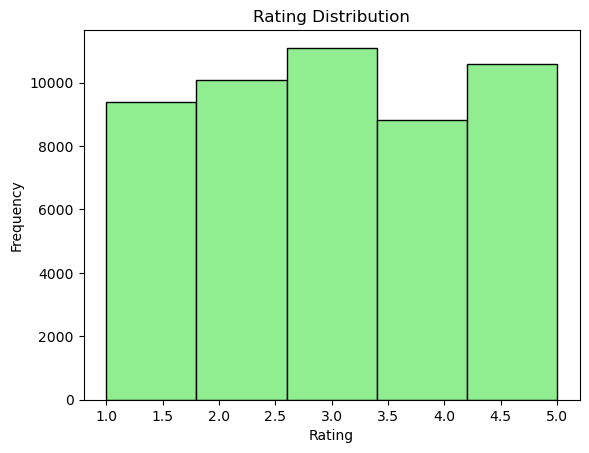

In [31]:
plt.figure()
plt.hist(data['rating'], bins=5, edgecolor='black', color='lightgreen')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

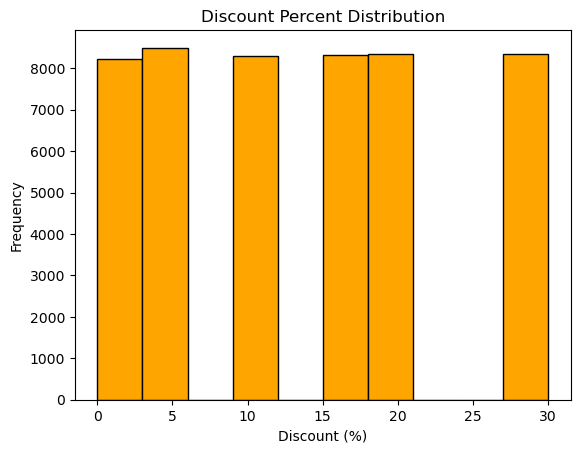

In [32]:
plt.figure()
plt.hist(data['discount_percent'], bins=10, edgecolor='black', color='orange')
plt.title('Discount Percent Distribution')
plt.xlabel('Discount (%)')
plt.ylabel('Frequency')
plt.show()

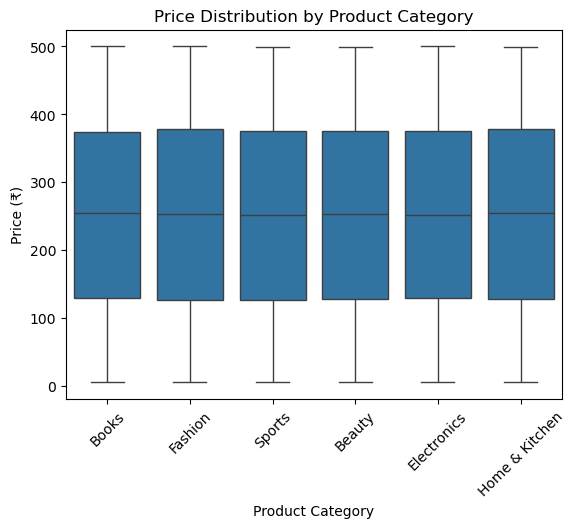

In [33]:
plt.figure()
sns.boxplot(x='product_category', y='price', data=data)
plt.title('Price Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.show()

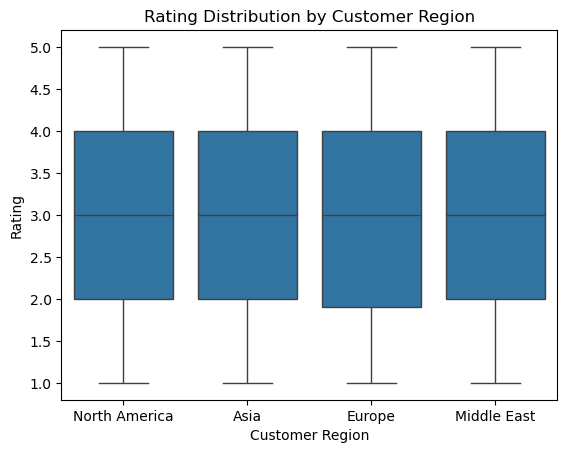

In [34]:
plt.figure()
sns.boxplot(x='customer_region', y='rating', data=data)
plt.title('Rating Distribution by Customer Region')
plt.xlabel('Customer Region')
plt.ylabel('Rating')
plt.show()

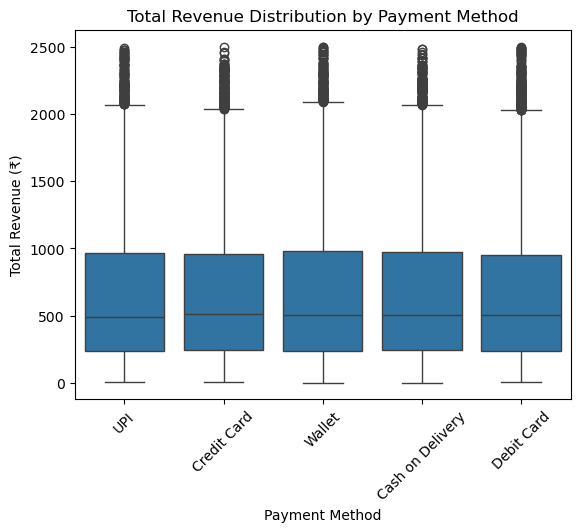

In [35]:
plt.figure()
sns.boxplot(x='payment_method', y='total_revenue', data=data)
plt.title('Total Revenue Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.show()

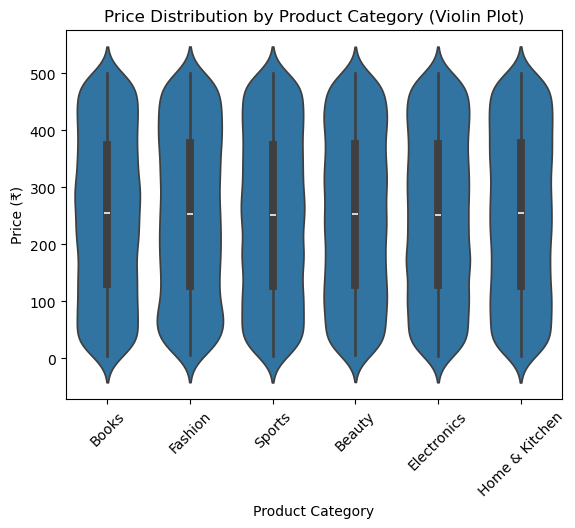

In [36]:
plt.figure()
sns.violinplot(x='product_category', y='price', data=data)
plt.title('Price Distribution by Product Category (Violin Plot)')
plt.xlabel('Product Category')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.show()

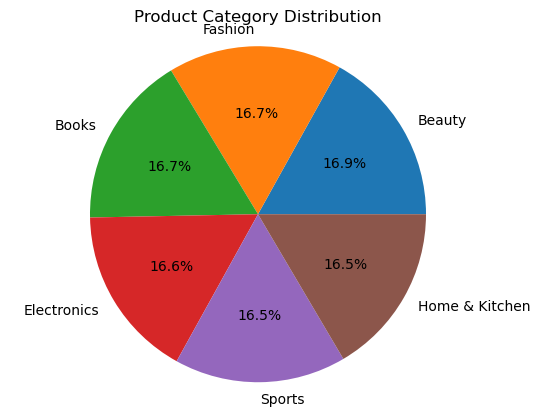

In [37]:
plt.figure()
category_counts = data['product_category'].value_counts()
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')
plt.title('Product Category Distribution')
plt.axis('equal')
plt.show()

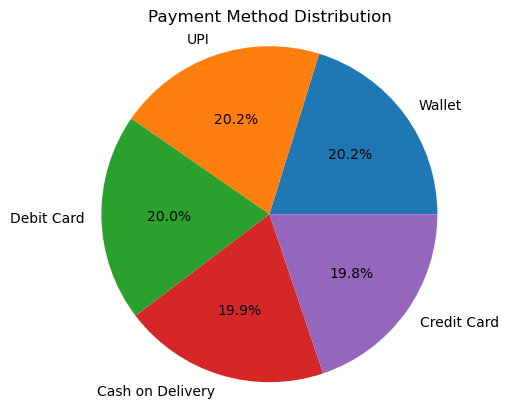

In [38]:
plt.figure()
payment_counts = data['payment_method'].value_counts()
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.axis('equal')
plt.show()

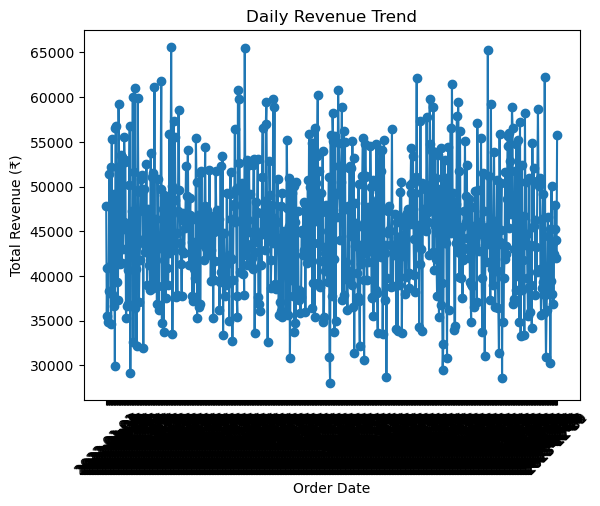

In [39]:
plt.figure()
daily_revenue = data.groupby('order_date')['total_revenue'].sum()
plt.plot(daily_revenue.index, daily_revenue.values, marker='o')
plt.title('Daily Revenue Trend')
plt.xlabel('Order Date')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.show()

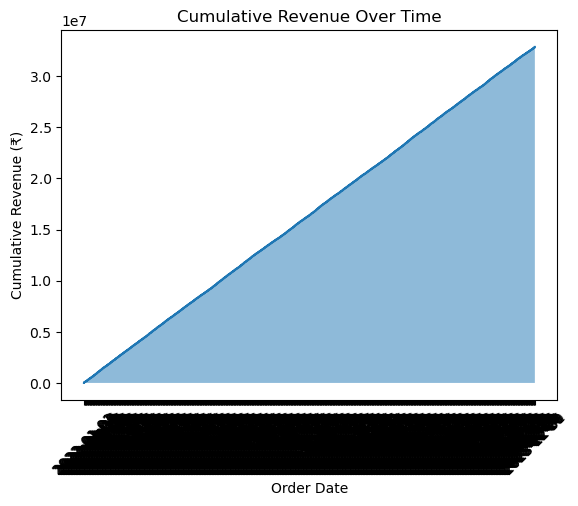

In [40]:
plt.figure()
df_sorted = data.sort_values('order_date')
df_sorted['cumulative_revenue'] = df_sorted['total_revenue'].cumsum()
plt.fill_between(df_sorted['order_date'], df_sorted['cumulative_revenue'], alpha=0.5)
plt.plot(df_sorted['order_date'], df_sorted['cumulative_revenue'])
plt.title('Cumulative Revenue Over Time')
plt.xlabel('Order Date')
plt.ylabel('Cumulative Revenue (₹)')
plt.xticks(rotation=45)
plt.show()

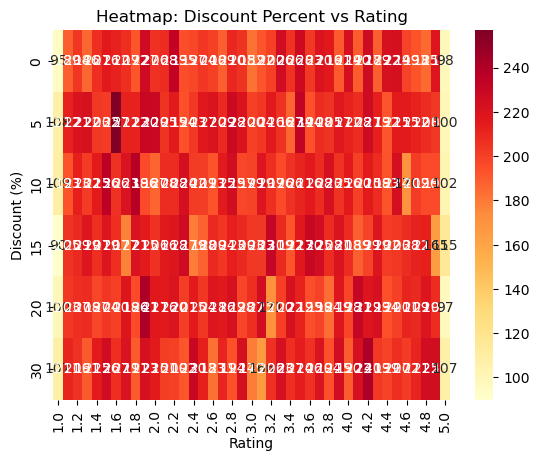

In [41]:
plt.figure()
discount_rating = pd.crosstab(data['discount_percent'], data['rating'])
sns.heatmap(discount_rating, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap: Discount Percent vs Rating')
plt.xlabel('Rating')
plt.ylabel('Discount (%)')
plt.show()

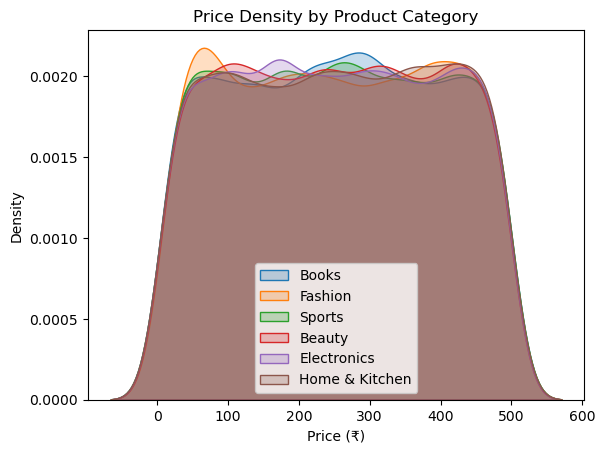

In [43]:
plt.figure()
for cat in data['product_category'].unique():
    subset = data[data['product_category'] == cat]
    sns.kdeplot(subset['price'], label=cat, shade=True)
plt.title('Price Density by Product Category')
plt.xlabel('Price (₹)')
plt.ylabel('Density')
plt.legend()
plt.show()

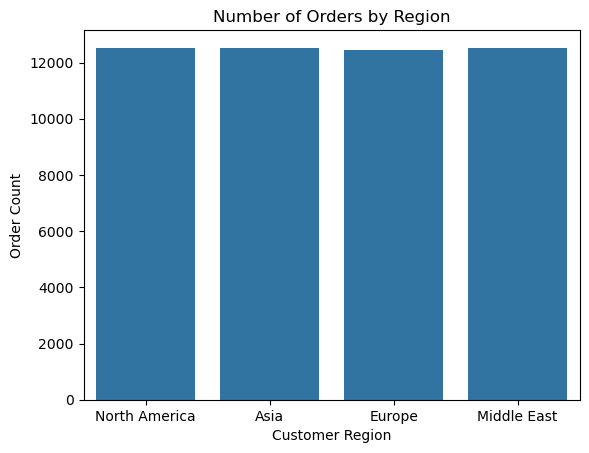

In [44]:
plt.figure()
sns.countplot(x='customer_region', data=data)
plt.title('Number of Orders by Region')
plt.xlabel('Customer Region')
plt.ylabel('Order Count')
plt.show()

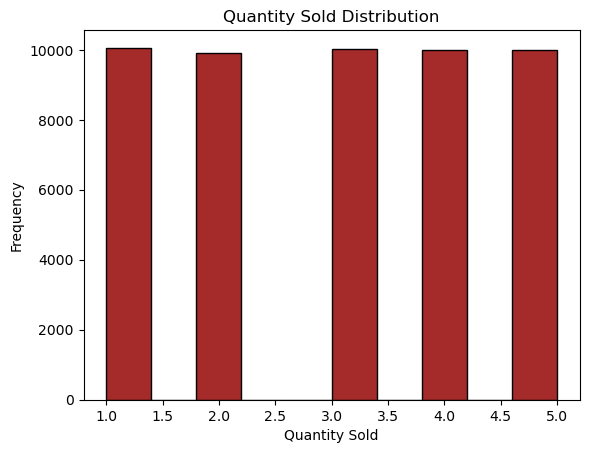

In [45]:
plt.figure()
plt.hist(data['quantity_sold'], bins=10, edgecolor='black', color='brown')
plt.title('Quantity Sold Distribution')
plt.xlabel('Quantity Sold')
plt.ylabel('Frequency')
plt.show()

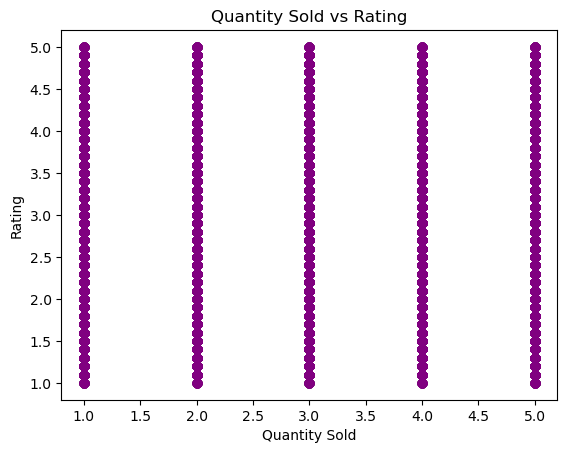

In [46]:
plt.figure()
plt.scatter(data['quantity_sold'], data['rating'], alpha=0.5, color='purple')
plt.title('Quantity Sold vs Rating')
plt.xlabel('Quantity Sold')
plt.ylabel('Rating')
plt.show()

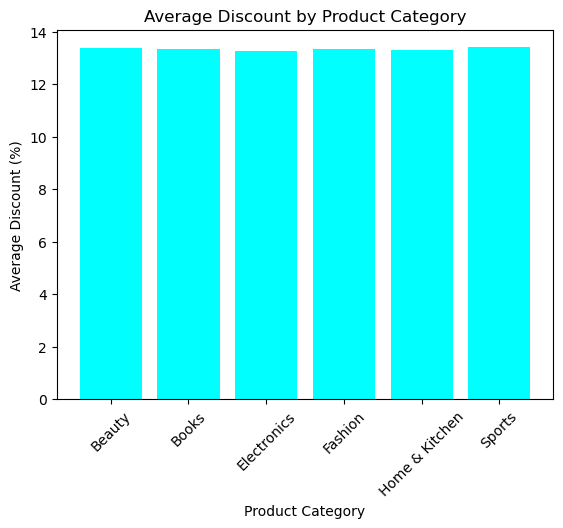

In [47]:
plt.figure()
cat_discount = data.groupby('product_category')['discount_percent'].mean()
plt.bar(cat_discount.index, cat_discount.values, color='cyan')
plt.title('Average Discount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Discount (%)')
plt.xticks(rotation=45)
plt.show()

In [48]:
import numpy as np
import pandas as pd

np.random.seed(42)
data = pd.DataFrame({
    'price': np.random.uniform(100, 5000, 500),
    'rating': np.random.choice([1,2,3,4,5], 500),
    'product_category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Beauty'], 500),
    'customer_region': np.random.choice(['North', 'South', 'East', 'West'], 500),
    'payment_method': np.random.choice(['Credit Card', 'PayPal', 'COD', 'Debit Card'], 500),
    'discount_percent': np.random.choice([0,5,10,15,20,25], 500),
    'quantity_sold': np.random.randint(1, 10, 500),
    'total_revenue': np.random.uniform(500, 50000, 500),
    'order_date': pd.date_range('2024-01-01', periods=500, freq='D')
})

In [49]:
# Simple CSV save
data.to_csv('ecommerce_data.csv', index=False)
print("✅ Data saved as 'ecommerce_data.csv'")

# With custom settings
data.to_csv('ecommerce_data.csv', index=False, encoding='utf-8')
print("✅ CSV file saved successfully!")

✅ Data saved as 'ecommerce_data.csv'
✅ CSV file saved successfully!
